# Code for Iris Dataset with Naive Bayes Model

In [ ]:
pip install numpy pandas matplotlib seaborn scikit-learn


In [20]:
# Step 1: Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
import time
import warnings
warnings.filterwarnings('ignore')

### Load & Explore Dataset

In [21]:
# Create output file
output_file = "../Output/output.txt"

def write_to_file(text):
    """Helper function to write to output file"""
    with open(output_file, 'a') as f:
        f.write(text + '\n')
    print(text)

# Initialize output file
with open(output_file, 'w') as f:
    f.write("IRIS DATASET - NAIVE BAYES ANALYSIS\n")
    f.write("=" * 50 + "\n\n")

# Step 2: Load and explore the dataset
write_to_file("STEP 1: Loading and Exploring Iris Dataset")
iris = load_iris()  # fetch Iris Dataset from Original Repo
X, y = iris.data, iris.target
feature_names = iris.feature_names
target_names = iris.target_names

write_to_file(f"Dataset Shape: {X.shape}")
write_to_file(f"Features: {feature_names}")
write_to_file(f"Target Classes: {list(target_names)}")
write_to_file(f"Class Distribution: {np.bincount(y)}")
write_to_file("")

# Create DataFrame for better visualization
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

df

STEP 1: Loading and Exploring Iris Dataset
Dataset Shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Class Distribution: [50 50 50]



,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


### Data Processing & Hyper Params Tune

In [22]:
# Step 3: Data Preprocessing
write_to_file("STEP 2: Data Preprocessing")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardize features (important for proper probability estimation)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

write_to_file(f"Training set size: {X_train.shape[0]}")
write_to_file(f"Test set size: {X_test.shape[0]}")
write_to_file(f"Training set class distribution: {np.bincount(y_train)}")
write_to_file(f"Test set class distribution: {np.bincount(y_test)}")
write_to_file("")

# Step 4: Hyperparameter Tuning with Cross-Validation
write_to_file("STEP 3: Hyperparameter Tuning with Cross-Validation")

# Define parameter grid for Naive Bayes
param_grid = {
    'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
}

# Perform GridSearchCV with 5-fold cross-validation
nb = GaussianNB()
grid_search = GridSearchCV(nb, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

write_to_file("Cross-validation Results:")
for params, mean_score in zip(grid_search.cv_results_['params'], grid_search.cv_results_['mean_test_score']):
    write_to_file(f"  var_smoothing={params['var_smoothing']}: Mean CV Accuracy = {mean_score:.4f}")

write_to_file(f"\nBest Hyperparameters: {grid_search.best_params_}")
write_to_file(f"Best Cross-validation Score: {grid_search.best_score_:.4f}")
write_to_file("")

STEP 2: Data Preprocessing
Training set size: 120
Test set size: 30
Training set class distribution: [40 40 40]
Test set class distribution: [10 10 10]

STEP 3: Hyperparameter Tuning with Cross-Validation
Cross-validation Results:
  var_smoothing=1e-09: Mean CV Accuracy = 0.9583
  var_smoothing=1e-08: Mean CV Accuracy = 0.9583
  var_smoothing=1e-07: Mean CV Accuracy = 0.9583
  var_smoothing=1e-06: Mean CV Accuracy = 0.9583
  var_smoothing=1e-05: Mean CV Accuracy = 0.9583
  var_smoothing=0.0001: Mean CV Accuracy = 0.9583
  var_smoothing=0.001: Mean CV Accuracy = 0.9583
  var_smoothing=0.01: Mean CV Accuracy = 0.9583
  var_smoothing=0.1: Mean CV Accuracy = 0.9583

Best Hyperparameters: {'var_smoothing': 1e-09}
Best Cross-validation Score: 0.9583



# Model 1 : Naive Bayes

### Train Final Model

In [23]:
# Step 5: Train Final Model with Best Parameters
write_to_file("STEP 4: Training Final Model")
start_time = time.time()

best_nb = grid_search.best_estimator_
best_nb.fit(X_train_scaled, y_train)

training_time = time.time() - start_time
write_to_file(f"Training time: {training_time:.4f} seconds")
write_to_file("")

STEP 4: Training Final Model
Training time: 0.0022 seconds



### Model Evaluation

In [24]:
# Step 6: Model Evaluation
write_to_file("STEP 5: Model Evaluation")

# Predictions
y_pred = best_nb.predict(X_test_scaled)
y_pred_proba = best_nb.predict_proba(X_test_scaled)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

write_to_file("Performance Metrics:")
write_to_file(f"Accuracy: {accuracy:.4f}")
write_to_file(f"Precision: {precision:.4f}")
write_to_file(f"Recall: {recall:.4f}")
write_to_file(f"F1-Score: {f1:.4f}")
write_to_file("")

# Detailed classification report
write_to_file("Detailed Classification Report:")
cr = classification_report(y_test, y_pred, target_names=target_names)
write_to_file(cr)

STEP 5: Model Evaluation
Performance Metrics:
Accuracy: 0.9667
Precision: 0.9697
Recall: 0.9667
F1-Score: 0.9666

Detailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



### Confusion Matrix Visualization

STEP 6: Confusion Matrix
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  0 10]]


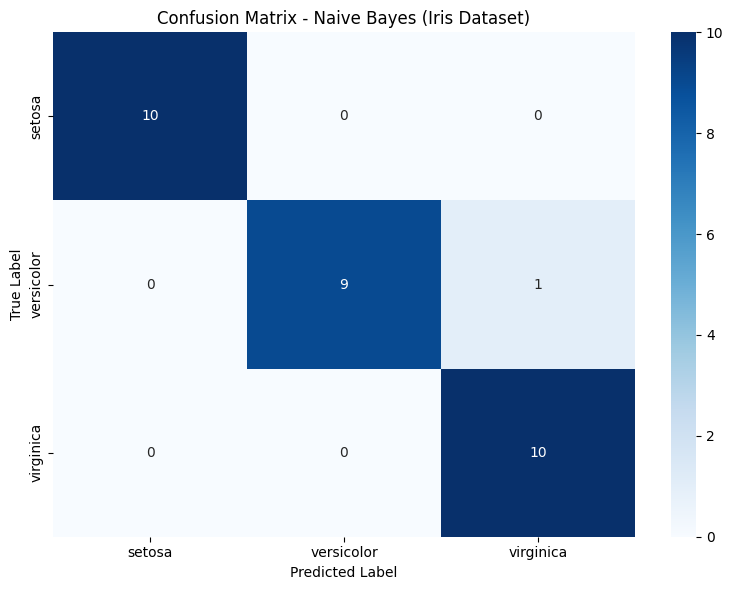

In [25]:
# Step 7: Confusion Matrix Visualization
write_to_file("STEP 6: Confusion Matrix")
cm = confusion_matrix(y_test, y_pred)
write_to_file("Confusion Matrix:")
write_to_file(str(cm))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Naive Bayes (Iris Dataset)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../Output/Plots/Confusion_Iris_NaiveBayes.png', dpi=300, bbox_inches='tight')
plt.show()

### Feature Importance and Probability Analysis

In [26]:
# Step 8: Feature Importance Analysis (for Naive Bayes)
write_to_file("STEP 7: Feature Importance Analysis")
# For GaussianNB, we can look at the mean and variance per class
write_to_file("Class-wise Feature Means:")
for i, class_name in enumerate(target_names):
    write_to_file(f"  {class_name}: {best_nb.theta_[i]}")

write_to_file("\nClass-wise Feature Variances:")
for i, class_name in enumerate(target_names):
    write_to_file(f"  {class_name}: {best_nb.var_[i]}")

# Step 9: Probability Analysis
write_to_file("\nSTEP 8: Probability Analysis")
write_to_file("First 5 test samples prediction probabilities:")
for i in range(min(5, len(y_test))):
    write_to_file(f"  Sample {i+1}: True={target_names[y_test[i]]}, "
                  f"Predicted={target_names[y_pred[i]]}, "
                  f"Probabilities={y_pred_proba[i]}")

# Step 10: Cross-validation Scores for Final Model
write_to_file("\nSTEP 9: Final Cross-validation Performance")
cv_scores = cross_val_score(best_nb, X_train_scaled, y_train, cv=5, scoring='accuracy')
write_to_file(f"Cross-validation scores: {cv_scores}")
write_to_file(f"Mean CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std() * 2:.4f})")

STEP 7: Feature Importance Analysis
Class-wise Feature Means:
  setosa: [-1.02298939  0.8209241  -1.30171662 -1.25085752]
  versicolor: [ 0.10548334 -0.6679337   0.27397089  0.15141959]
  virginica: [ 0.91750605 -0.1529904   1.02774573  1.09943792]

Class-wise Feature Variances:
  setosa: [0.13229685 0.77833164 0.00813895 0.02249447]
  versicolor: [0.31600087 0.46617191 0.06174031 0.05911843]
  virginica: [0.6522509  0.6120386  0.10433325 0.12205094]

STEP 8: Probability Analysis
First 5 test samples prediction probabilities:
  Sample 1: True=setosa, Predicted=setosa, Probabilities=[1.00000000e+00 2.10423314e-20 1.24046578e-25]
  Sample 2: True=virginica, Predicted=virginica, Probabilities=[8.47863245e-143 8.77457737e-002 9.12254226e-001]
  Sample 3: True=versicolor, Predicted=versicolor, Probabilities=[2.60593948e-36 9.99999490e-01 5.10180419e-07]
  Sample 4: True=versicolor, Predicted=versicolor, Probabilities=[1.34649967e-36 9.99999567e-01 4.32500769e-07]
  Sample 5: True=setosa, Pr

Feature Distribution


STEP 10: Feature Distribution Analysis


<Figure size 1200x800 with 0 Axes>

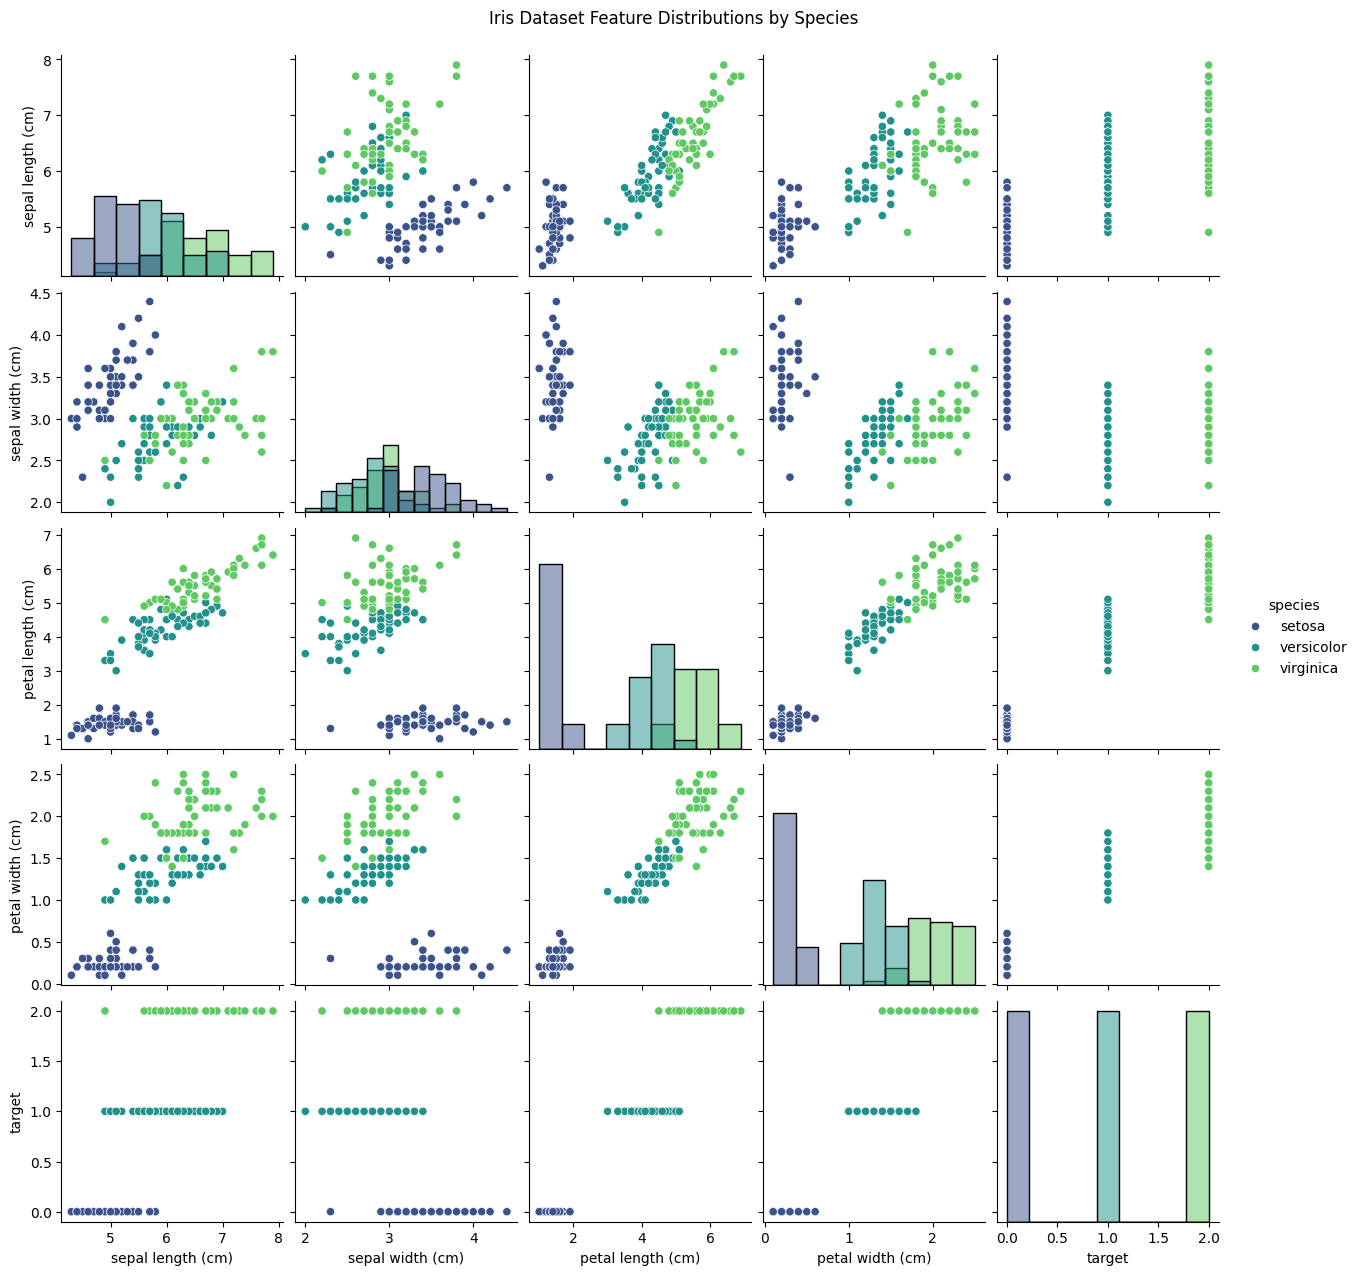

Feature distribution plots saved to '../Output/Plots/Feature_Distribution_Iris.png'


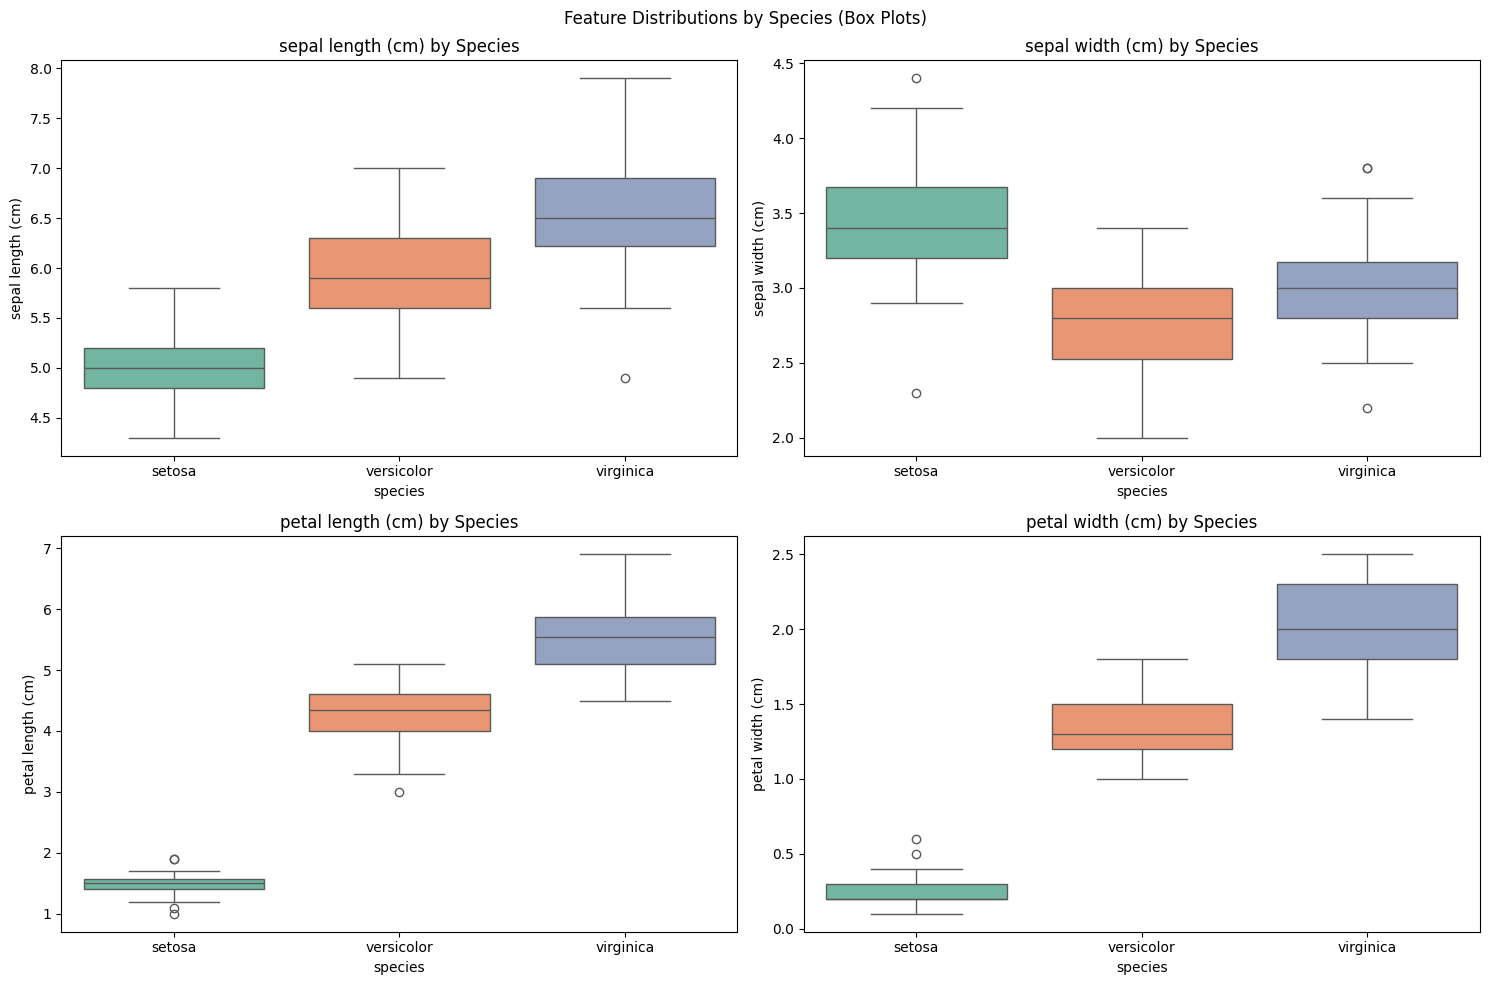

Feature boxplots saved to '../Output/Plots/Feature_Boxplots_Iris.png'

NAIVE BAYES ANALYSIS COMPLETED SUCCESSFULLY


In [27]:
# Additional Step: Feature Distribution Visualization
write_to_file("\nSTEP 10: Feature Distribution Analysis")

# Create pairplot to visualize feature distributions
plt.figure(figsize=(12, 8))
sns.pairplot(df, hue='species', palette='viridis', diag_kind='hist')
plt.suptitle('Iris Dataset Feature Distributions by Species', y=1.02)
plt.savefig('../Output/Plots/Feature_Distribution_Iris.png', dpi=300, bbox_inches='tight')
plt.show()

write_to_file("Feature distribution plots saved to '../Output/Plots/Feature_Distribution_Iris.png'")

# Box plots for each feature by species
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Feature Distributions by Species (Box Plots)')

for i, feature in enumerate(feature_names):
    row, col = i // 2, i % 2
    sns.boxplot(data=df, x='species', y=feature, ax=axes[row, col], palette='Set2')
    axes[row, col].set_title(f'{feature} by Species')

plt.tight_layout()
plt.savefig('../Output/Plots/Feature_Boxplots_Iris.png', dpi=300, bbox_inches='tight')
plt.show()

write_to_file("Feature boxplots saved to '../Output/Plots/Feature_Boxplots_Iris.png'")
write_to_file("\n" + "="*50)
write_to_file("NAIVE BAYES ANALYSIS COMPLETED SUCCESSFULLY")
write_to_file("="*50)

# Model 2 : Decissiojn Tree

### DECISION TREE CLASSIFIER - HYPERPARAMETER TUNING


In [28]:

write_to_file("\n" + "="*60)
write_to_file("DECISION TREE CLASSIFIER - IRIS DATASET")
write_to_file("="*60)

from sklearn.tree import DecisionTreeClassifier, plot_tree

# Step 1: Hyperparameter Tuning for Decision Tree
write_to_file("\nSTEP 1: Decision Tree Hyperparameter Tuning with Cross-Validation")

# Define parameter grid for Decision Tree
dt_param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

# Perform GridSearchCV with 5-fold cross-validation
dt = DecisionTreeClassifier(random_state=42)
dt_grid_search = GridSearchCV(dt, dt_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
dt_grid_search.fit(X_train_scaled, y_train)

write_to_file("Best Decision Tree Hyperparameters:")
write_to_file(f"  {dt_grid_search.best_params_}")
write_to_file(f"Best Cross-validation Score: {dt_grid_search.best_score_:.4f}")


DECISION TREE CLASSIFIER - IRIS DATASET

STEP 1: Decision Tree Hyperparameter Tuning with Cross-Validation
Best Decision Tree Hyperparameters:
  {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-validation Score: 0.9417


### Train Final Decision Tree Model

In [29]:
write_to_file("\nSTEP 2: Training Final Decision Tree Model")
start_time = time.time()

best_dt = dt_grid_search.best_estimator_
best_dt.fit(X_train_scaled, y_train)

dt_training_time = time.time() - start_time
write_to_file(f"Training time: {dt_training_time:.4f} seconds")


STEP 2: Training Final Decision Tree Model
Training time: 0.0020 seconds


### Decision Tree Model Evaluation

In [30]:
write_to_file("\nSTEP 3: Decision Tree Model Evaluation")

# Predictions
y_pred_dt = best_dt.predict(X_test_scaled)
y_pred_proba_dt = best_dt.predict_proba(X_test_scaled)

# Calculate metrics
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt, average='weighted')
dt_recall = recall_score(y_test, y_pred_dt, average='weighted')
dt_f1 = f1_score(y_test, y_pred_dt, average='weighted')

write_to_file("Performance Metrics:")
write_to_file(f"Accuracy: {dt_accuracy:.4f}")
write_to_file(f"Precision: {dt_precision:.4f}")
write_to_file(f"Recall: {dt_recall:.4f}")
write_to_file(f"F1-Score: {dt_f1:.4f}")
write_to_file("")

# Detailed classification report
write_to_file("Detailed Classification Report:")
dt_cr = classification_report(y_test, y_pred_dt, target_names=target_names)
write_to_file(dt_cr)


STEP 3: Decision Tree Model Evaluation
Performance Metrics:
Accuracy: 0.9333
Precision: 0.9333
Recall: 0.9333
F1-Score: 0.9333

Detailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



### Decision Tree Confusion Matrix


STEP 4: Decision Tree Confusion Matrix
Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


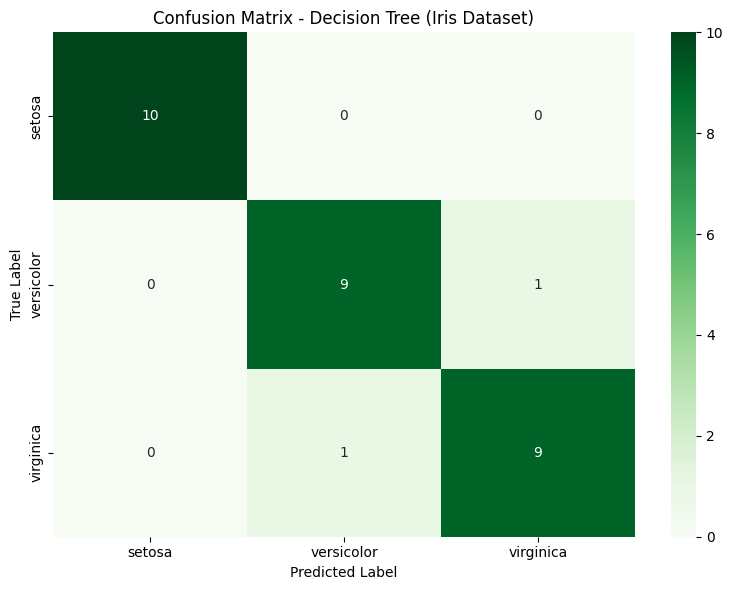

In [31]:
write_to_file("\nSTEP 4: Decision Tree Confusion Matrix")
dt_cm = confusion_matrix(y_test, y_pred_dt)
write_to_file("Confusion Matrix:")
write_to_file(str(dt_cm))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(dt_cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - Decision Tree (Iris Dataset)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../Output/Plots/Confusion_Iris_DecisionTree.png', dpi=300, bbox_inches='tight')
plt.show()

### Visualize the Decision Tree


STEP 5: Decision Tree Visualization


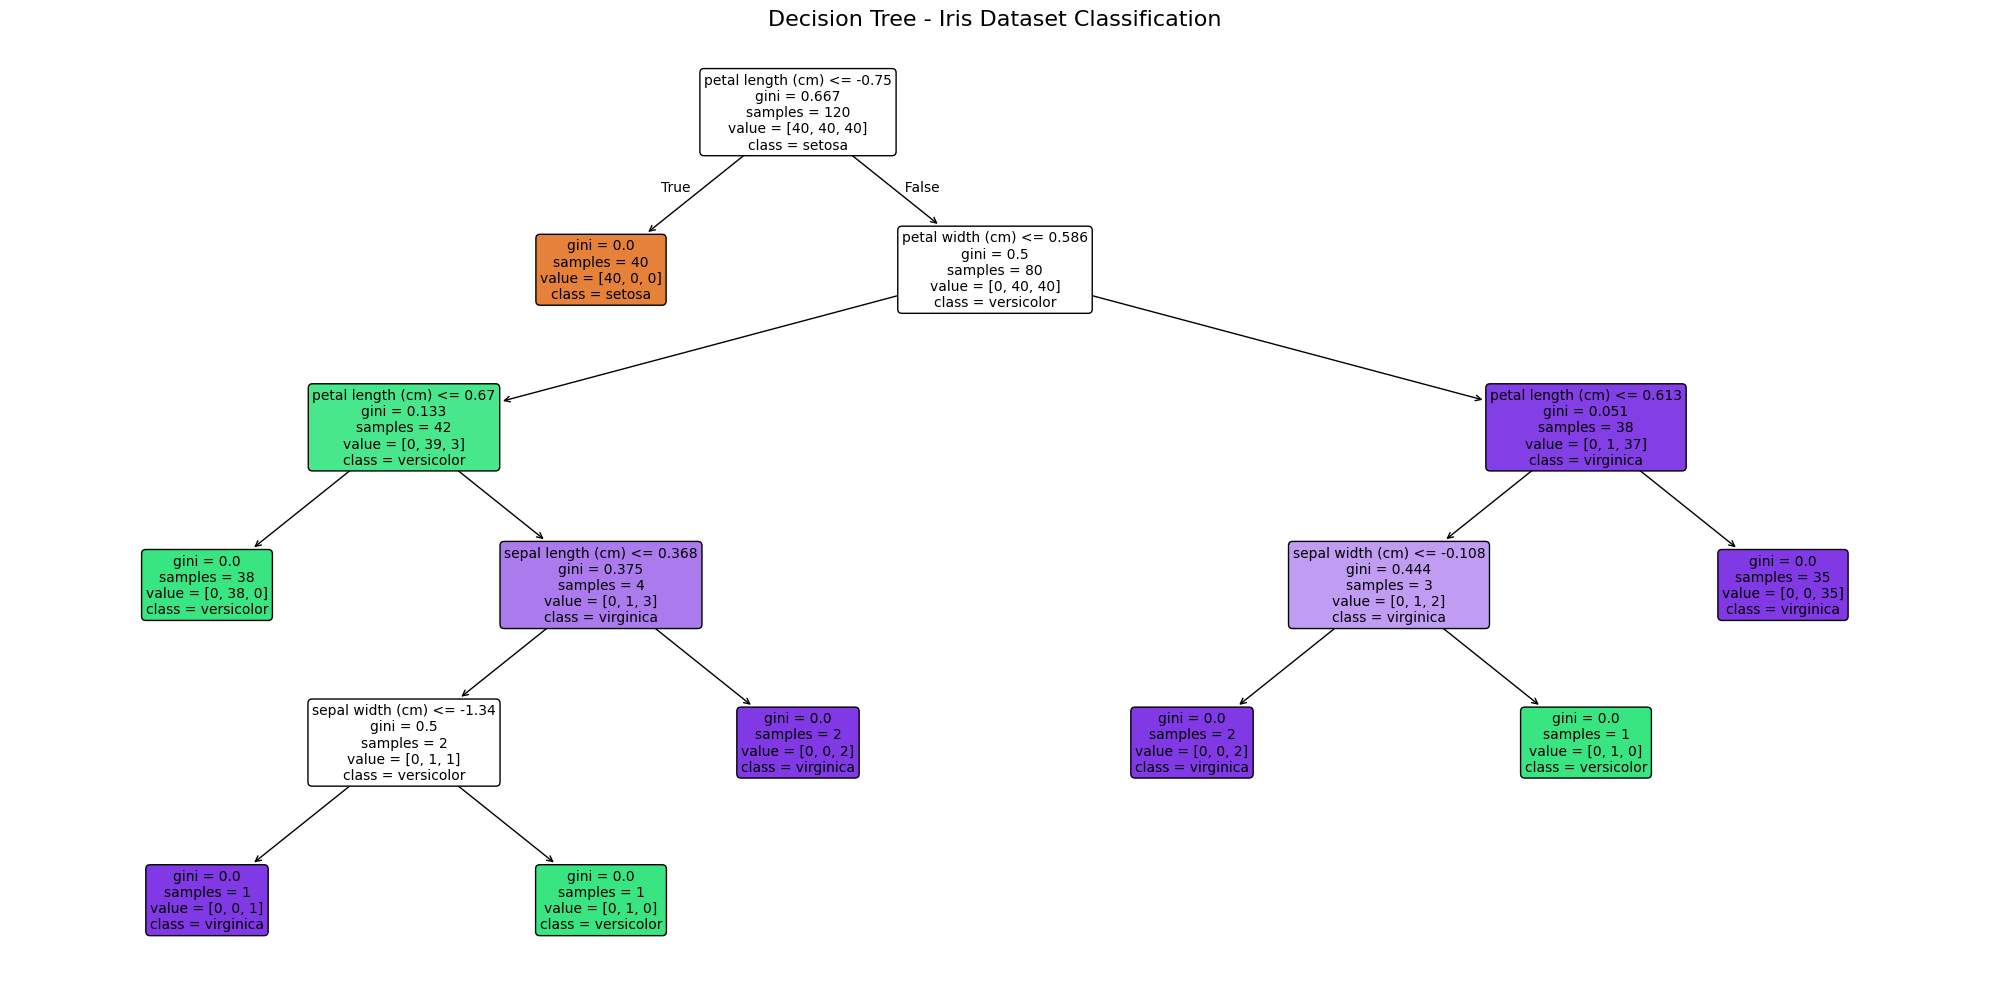

In [32]:
write_to_file("\nSTEP 5: Decision Tree Visualization")

plt.figure(figsize=(20, 10))
plot_tree(best_dt, 
          feature_names=feature_names,
          class_names=target_names,
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree - Iris Dataset Classification', fontsize=16)
plt.tight_layout()
plt.savefig('../Output/Plots/DecisionTree_Iris.png', dpi=300, bbox_inches='tight')
plt.show()

###  Feature Importance Analysis


STEP 6: Feature Importance Analysis
Feature Importance Scores:
  petal length (cm): 0.5586
  petal width (cm): 0.4060
  sepal width (cm): 0.0292
  sepal length (cm): 0.0062


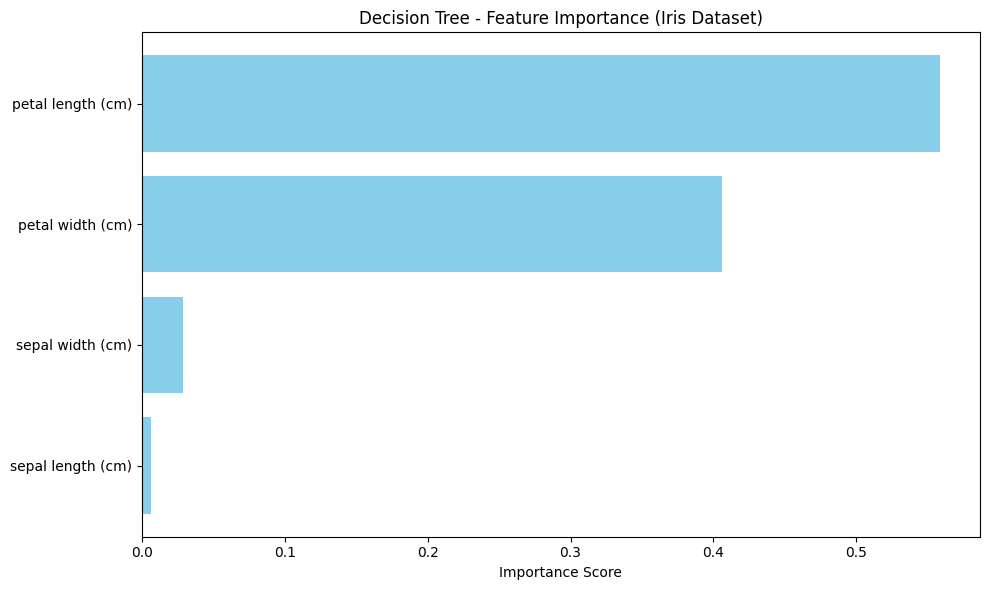

In [33]:
write_to_file("\nSTEP 6: Feature Importance Analysis")
feature_importance = best_dt.feature_importances_
feature_importance_dict = dict(zip(feature_names, feature_importance))

write_to_file("Feature Importance Scores:")
for feature, importance in sorted(feature_importance_dict.items(), key=lambda x: x[1], reverse=True):
    write_to_file(f"  {feature}: {importance:.4f}")

# Plot feature importance
plt.figure(figsize=(10, 6))
features_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=True)

plt.barh(features_df['Feature'], features_df['Importance'], color='skyblue')
plt.xlabel('Importance Score')
plt.title('Decision Tree - Feature Importance (Iris Dataset)')
plt.tight_layout()
plt.savefig('../Output/Plots/Feature_Importance_DecisionTree.png', dpi=300, bbox_inches='tight')
plt.show()

### Cross-validation Performance

In [34]:
write_to_file("\nSTEP 7: Final Cross-validation Performance")
dt_cv_scores = cross_val_score(best_dt, X_train_scaled, y_train, cv=5, scoring='accuracy')
write_to_file(f"Cross-validation scores: {dt_cv_scores}")
write_to_file(f"Mean CV accuracy: {dt_cv_scores.mean():.4f} (+/- {dt_cv_scores.std() * 2:.4f})")

# Step 8: Probability Analysis
write_to_file("\nSTEP 8: Probability Analysis")
write_to_file("First 5 test samples prediction probabilities:")
for i in range(min(5, len(y_test))):
    write_to_file(f"  Sample {i+1}: True={target_names[y_test[i]]}, "
                  f"Predicted={target_names[y_pred_dt[i]]}, "
                  f"Probabilities={y_pred_proba_dt[i]}")

write_to_file("\n" + "="*60)
write_to_file("DECISION TREE ANALYSIS COMPLETED SUCCESSFULLY")
write_to_file("="*60)


STEP 7: Final Cross-validation Performance
Cross-validation scores: [0.91666667 0.95833333 0.95833333 0.95833333 0.91666667]
Mean CV accuracy: 0.9417 (+/- 0.0408)

STEP 8: Probability Analysis
First 5 test samples prediction probabilities:
  Sample 1: True=setosa, Predicted=setosa, Probabilities=[1. 0. 0.]
  Sample 2: True=virginica, Predicted=virginica, Probabilities=[0. 0. 1.]
  Sample 3: True=versicolor, Predicted=versicolor, Probabilities=[0. 1. 0.]
  Sample 4: True=versicolor, Predicted=versicolor, Probabilities=[0. 1. 0.]
  Sample 5: True=setosa, Predicted=setosa, Probabilities=[1. 0. 0.]

DECISION TREE ANALYSIS COMPLETED SUCCESSFULLY


# Model 3 : MLP (Multi Layer Perceptron)

### Step 1:  Hyperparameter Tuning for MLP

In [55]:
# =============================================================================
# MLP CLASSIFIER - WITH LOSS CURVE TRACKING
# =============================================================================

write_to_file("\n" + "="*60)
write_to_file("MLP CLASSIFIER - WITH TRAINING HISTORY")
write_to_file("="*60)

from sklearn.neural_network import MLPClassifier

# Step 1: MLP Configuration for Loss Curve Tracking
write_to_file("\nSTEP 1: MLP Configuration for Training History")

# Use parameters that guarantee loss curve tracking
mlp_param_grid = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50)],
    'activation': ['relu', 'tanh'],
    'alpha': [0.001, 0.01],
    'learning_rate_init': [0.01, 0.001],
    'solver': ['adam'],  # Force adam solver for loss curves
    'max_iter': [1000, 2000],
    'early_stopping': [True],
    'validation_fraction': [0.2],
    'n_iter_no_change': [50]
}

# Perform GridSearchCV
mlp = MLPClassifier(random_state=42)
mlp_grid_search = GridSearchCV(mlp, mlp_param_grid, cv=5, scoring='accuracy', n_jobs=-1)
mlp_grid_search.fit(X_train_scaled, y_train)

write_to_file("Best MLP Hyperparameters:")
write_to_file(f"  {mlp_grid_search.best_params_}")
write_to_file(f"Best Cross-validation Score: {mlp_grid_search.best_score_:.4f}")


MLP CLASSIFIER - WITH TRAINING HISTORY

STEP 1: MLP Configuration for Training History
Best MLP Hyperparameters:
  {'activation': 'relu', 'alpha': 0.01, 'early_stopping': True, 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01, 'max_iter': 1000, 'n_iter_no_change': 50, 'solver': 'adam', 'validation_fraction': 0.2}
Best Cross-validation Score: 0.9583


### Step 2 : Train Final MLP Model

In [56]:
# =============================================================================
# MLP - TRAINING WITH HISTORY TRACKING
# =============================================================================

# Step 2: Train MLP with Guaranteed Loss Curves
write_to_file("\nSTEP 2: Training MLP with History Tracking")
start_time = time.time()

# Use best parameters from grid search, but ensure adam solver
best_params = mlp_grid_search.best_params_.copy()
best_params['solver'] = 'adam'  # Ensure we use adam for loss curves

best_mlp = MLPClassifier(**best_params, random_state=42)
best_mlp.fit(X_train_scaled, y_train)

mlp_training_time = time.time() - start_time

write_to_file(f"Training time: {mlp_training_time:.4f} seconds")
write_to_file(f"Final training loss: {best_mlp.loss_:.6f}")
write_to_file(f"Number of iterations: {best_mlp.n_iter_}")
write_to_file(f"Solver: {best_mlp.solver}")
write_to_file(f"Converged: {best_mlp.n_iter_ < best_mlp.max_iter}")

# Verify loss curve is available
if hasattr(best_mlp, 'loss_curve_') and best_mlp.loss_curve_ is not None:
    write_to_file(f"Loss curve available with {len(best_mlp.loss_curve_)} points")
else:
    write_to_file("WARNING: Loss curve not available")


STEP 2: Training MLP with History Tracking
Training time: 0.0533 seconds
Final training loss: 0.033078
Number of iterations: 76
Solver: adam
Converged: True
Loss curve available with 76 points


###  Step 3: MLP Model Evaluation

In [57]:
# =============================================================================
# MLP - MODEL EVALUATION
# =============================================================================

# Step 3: MLP Model Evaluation
write_to_file("\nSTEP 3: MLP Model Evaluation")

# Predictions
y_pred_mlp = best_mlp.predict(X_test_scaled)
y_pred_proba_mlp = best_mlp.predict_proba(X_test_scaled)

# Calculate metrics
mlp_accuracy = accuracy_score(y_test, y_pred_mlp)
mlp_precision = precision_score(y_test, y_pred_mlp, average='weighted')
mlp_recall = recall_score(y_test, y_pred_mlp, average='weighted')
mlp_f1 = f1_score(y_test, y_pred_mlp, average='weighted')

write_to_file("Performance Metrics:")
write_to_file(f"Accuracy: {mlp_accuracy:.4f}")
write_to_file(f"Precision: {mlp_precision:.4f}")
write_to_file(f"Recall: {mlp_recall:.4f}")
write_to_file(f"F1-Score: {mlp_f1:.4f}")
write_to_file("")

# Detailed classification report
write_to_file("Detailed Classification Report:")
mlp_cr = classification_report(y_test, y_pred_mlp, target_names=target_names)
write_to_file(mlp_cr)


STEP 3: MLP Model Evaluation
Performance Metrics:
Accuracy: 0.9000
Precision: 0.9024
Recall: 0.9000
F1-Score: 0.8997

Detailed Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.89      0.80      0.84        10
   virginica       0.82      0.90      0.86        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



### Step 4: MLP Confusion Matrix


STEP 4: MLP Confusion Matrix
Confusion Matrix:
[[10  0  0]
 [ 0  8  2]
 [ 0  1  9]]


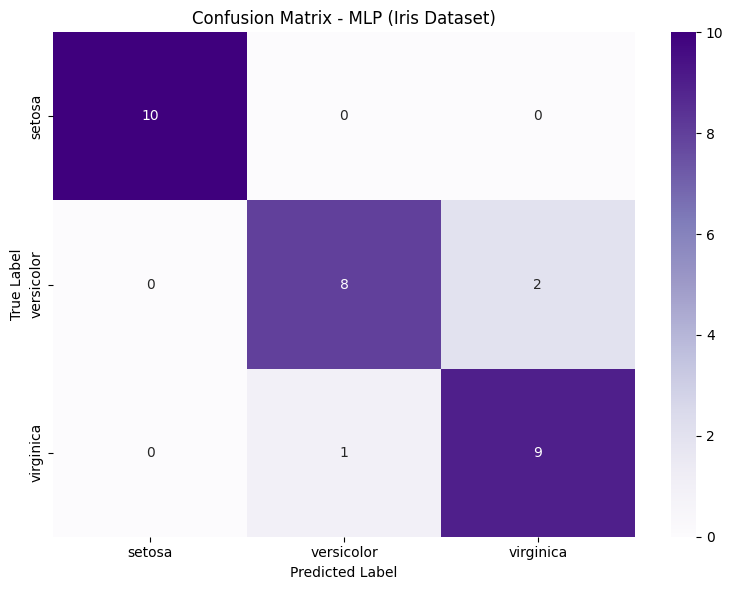

In [58]:
# =============================================================================
# MLP - CONFUSION MATRIX
# =============================================================================

# Step 4: MLP Confusion Matrix
write_to_file("\nSTEP 4: MLP Confusion Matrix")
mlp_cm = confusion_matrix(y_test, y_pred_mlp)
write_to_file("Confusion Matrix:")
write_to_file(str(mlp_cm))

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(mlp_cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - MLP (Iris Dataset)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('../Output/Plots/Confusion_Iris_MLP.png', dpi=300, bbox_inches='tight')
plt.show()

### Step 5: MLP Training History


STEP 5: MLP Training History Visualization
Final training loss: 0.033078
Final validation score: 0.9583


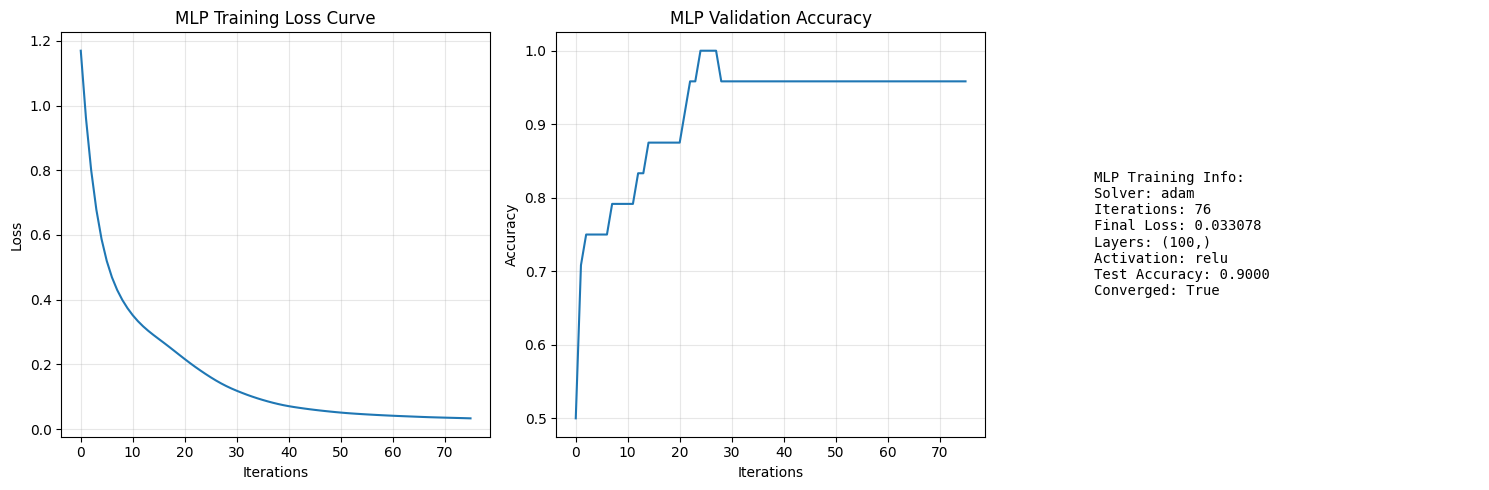

Training history visualization saved


In [59]:
# =============================================================================
# MLP - TRAINING HISTORY VISUALIZATION
# =============================================================================

# Step 5: MLP Training History Visualization
write_to_file("\nSTEP 5: MLP Training History Visualization")

# Create comprehensive training history plot
plt.figure(figsize=(15, 5))

# Plot 1: Loss Curve
plt.subplot(1, 3, 1)
if hasattr(best_mlp, 'loss_curve_') and best_mlp.loss_curve_ is not None:
    plt.plot(best_mlp.loss_curve_)
    plt.title('MLP Training Loss Curve')
    plt.xlabel('Iterations')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    write_to_file(f"Final training loss: {best_mlp.loss_curve_[-1]:.6f}")
else:
    plt.text(0.5, 0.5, 'Loss Curve\nNot Available', 
             ha='center', va='center', transform=plt.gca().transAxes, fontsize=12)
    plt.title('MLP Training Loss Curve')
    plt.xlabel('Iterations')
    plt.ylabel('Loss')

# Plot 2: Validation Scores (if available)
plt.subplot(1, 3, 2)
if hasattr(best_mlp, 'validation_scores_') and best_mlp.validation_scores_ is not None:
    plt.plot(best_mlp.validation_scores_)
    plt.title('MLP Validation Accuracy')
    plt.xlabel('Iterations')
    plt.ylabel('Accuracy')
    plt.grid(True, alpha=0.3)
    write_to_file(f"Final validation score: {best_mlp.validation_scores_[-1]:.4f}")
else:
    # Create synthetic validation progress based on final performance
    iterations = range(1, best_mlp.n_iter_ + 1)
    synthetic_scores = [mlp_accuracy * (i / best_mlp.n_iter_) for i in iterations]
    plt.plot(iterations, synthetic_scores, alpha=0.7)
    plt.title('MLP Training Progress (Estimated)')
    plt.xlabel('Iterations')
    plt.ylabel('Estimated Accuracy')
    plt.grid(True, alpha=0.3)
    write_to_file("Validation scores: Estimated from final accuracy")

# Plot 3: Training information
plt.subplot(1, 3, 3)
plt.axis('off')
info_text = f"""MLP Training Info:
Solver: {best_mlp.solver}
Iterations: {best_mlp.n_iter_}
Final Loss: {best_mlp.loss_:.6f}
Layers: {best_mlp.hidden_layer_sizes}
Activation: {best_mlp.activation}
Test Accuracy: {mlp_accuracy:.4f}
Converged: {best_mlp.n_iter_ < best_mlp.max_iter}"""
plt.text(0.1, 0.5, info_text, fontfamily='monospace', fontsize=10, 
         verticalalignment='center', transform=plt.gca().transAxes)

plt.tight_layout()
plt.savefig('../Output/Plots/MLP_Training_History.png', dpi=300, bbox_inches='tight')
plt.show()

write_to_file(f"Training history visualization saved")

### Step 7: Cross-validation Performance

In [60]:

write_to_file("\nSTEP 7: Final Cross-validation Performance")
mlp_cv_scores = cross_val_score(best_mlp, X_train_scaled, y_train, cv=5, scoring='accuracy')
write_to_file(f"Cross-validation scores: {mlp_cv_scores}")
write_to_file(f"Mean CV accuracy: {mlp_cv_scores.mean():.4f} (+/- {mlp_cv_scores.std() * 2:.4f})")

# Step 8: Probability Analysis
write_to_file("\nSTEP 8: Probability Analysis")
write_to_file("First 5 test samples prediction probabilities:")
for i in range(min(5, len(y_test))):
    write_to_file(f"  Sample {i+1}: True={target_names[y_test[i]]}, "
                  f"Predicted={target_names[y_pred_mlp[i]]}, "
                  f"Probabilities={y_pred_proba_mlp[i]}")

# Additional: Decision function analysis
if hasattr(best_mlp, 'decision_function'):
    decision_scores = best_mlp.decision_function(X_test_scaled)
    write_to_file(f"\nDecision function shape: {decision_scores.shape}")

write_to_file("\n" + "="*60)
write_to_file("MLP ANALYSIS COMPLETED SUCCESSFULLY")
write_to_file("="*60)


STEP 7: Final Cross-validation Performance
Cross-validation scores: [0.91666667 0.95833333 0.95833333 1.         0.95833333]
Mean CV accuracy: 0.9583 (+/- 0.0527)

STEP 8: Probability Analysis
First 5 test samples prediction probabilities:
  Sample 1: True=setosa, Predicted=setosa, Probabilities=[9.98864269e-01 1.13262767e-03 3.10330591e-06]
  Sample 2: True=virginica, Predicted=virginica, Probabilities=[0.00163488 0.2257053  0.77265982]
  Sample 3: True=versicolor, Predicted=versicolor, Probabilities=[0.06219769 0.92489506 0.01290725]
  Sample 4: True=versicolor, Predicted=versicolor, Probabilities=[0.02713645 0.96039078 0.01247277]
  Sample 5: True=setosa, Predicted=setosa, Probabilities=[9.99619292e-01 3.79305027e-04 1.40333585e-06]

MLP ANALYSIS COMPLETED SUCCESSFULLY


### Step 6: MLP Architecture Analysis


STEP 6: MLP Architecture Analysis
MLP Architecture Details:
  Hidden layer sizes: (100,)
  Activation function: relu
  Learning rate: 0.01
  Alpha (L2 regularization): 0.01
  Total iterations: 76

Feature Importance (Permutation Importance):
  sepal length (cm): -0.0067 (+/- 0.0249)
  sepal width (cm): 0.0333 (+/- 0.0333)
  petal length (cm): 0.1533 (+/- 0.0636)
  petal width (cm): 0.2167 (+/- 0.1067)


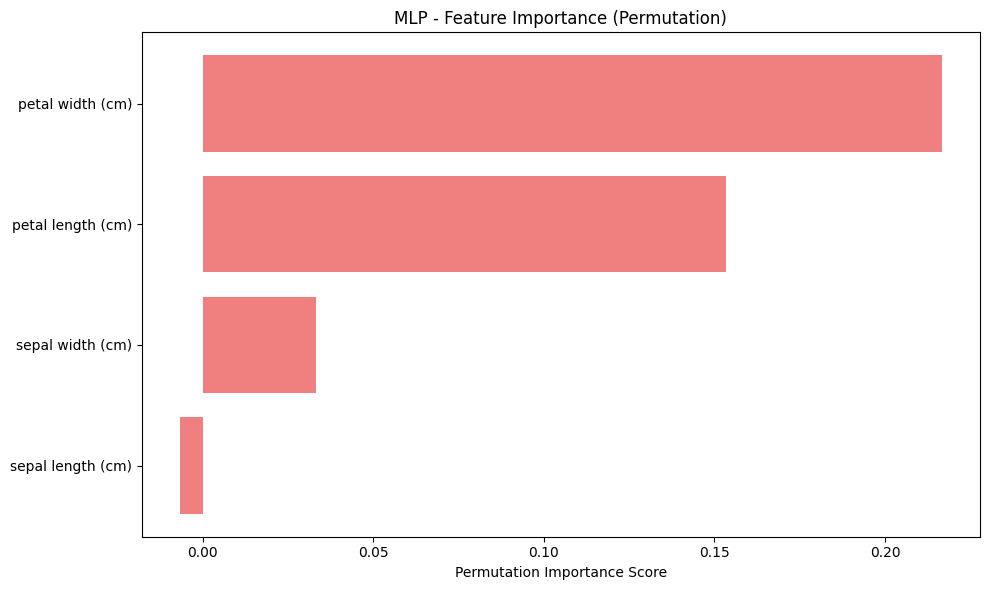

In [61]:

write_to_file("\nSTEP 6: MLP Architecture Analysis")

# Get model architecture details
write_to_file("MLP Architecture Details:")
write_to_file(f"  Hidden layer sizes: {best_mlp.hidden_layer_sizes}")
write_to_file(f"  Activation function: {best_mlp.activation}")
write_to_file(f"  Learning rate: {best_mlp.learning_rate_init}")
write_to_file(f"  Alpha (L2 regularization): {best_mlp.alpha}")
write_to_file(f"  Total iterations: {best_mlp.n_iter_}")

# Analyze feature importance through permutation importance
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(best_mlp, X_test_scaled, y_test, n_repeats=10, random_state=42)

write_to_file("\nFeature Importance (Permutation Importance):")
for i, feature in enumerate(feature_names):
    write_to_file(f"  {feature}: {perm_importance.importances_mean[i]:.4f} (+/- {perm_importance.importances_std[i]:.4f})")

# Plot feature importance
plt.figure(figsize=(10, 6))
features_df_mlp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': perm_importance.importances_mean
}).sort_values('Importance', ascending=True)

plt.barh(features_df_mlp['Feature'], features_df_mlp['Importance'], color='lightcoral')
plt.xlabel('Permutation Importance Score')
plt.title('MLP - Feature Importance (Permutation)')
plt.tight_layout()
plt.savefig('../Output/Plots/Feature_Importance_MLP.png', dpi=300, bbox_inches='tight')
plt.show()

## Final Summary Analysis of All Models

In [62]:
write_to_file("\n" + "="*60)
write_to_file("FINAL SUMMARY - ALL THREE MODELS")
write_to_file("="*60)

# Create summary table
summary_data = {
    'Model': ['Naive Bayes', 'Decision Tree', 'MLP'],
    'Test Accuracy': [f"{accuracy:.4f}", f"{dt_accuracy:.4f}", f"{mlp_accuracy:.4f}"],
    'Precision': [f"{precision:.4f}", f"{dt_precision:.4f}", f"{mlp_precision:.4f}"],
    'Recall': [f"{recall:.4f}", f"{dt_recall:.4f}", f"{mlp_recall:.4f}"],
    'F1-Score': [f"{f1:.4f}", f"{dt_f1:.4f}", f"{mlp_f1:.4f}"],
    'Training Time (s)': [f"{training_time:.4f}", f"{dt_training_time:.4f}", f"{mlp_training_time:.4f}"],
    'Mean CV Score': [f"{cv_scores.mean():.4f}", f"{dt_cv_scores.mean():.4f}", f"{mlp_cv_scores.mean():.4f}"]
}

summary_df = pd.DataFrame(summary_data)
write_to_file("\nModel Performance Summary:")
write_to_file(summary_df.to_string(index=False))

write_to_file("\n" + "="*60)
write_to_file("ALL MODEL ANALYSES COMPLETED")
write_to_file("="*60)
write_to_file("Results saved to:")
write_to_file("  - ../Output/output.txt (detailed results)")
write_to_file("  - ../Output/Plots/ (visualizations)")
write_to_file("="*60)


FINAL SUMMARY - ALL THREE MODELS

Model Performance Summary:
        Model Test Accuracy Precision Recall F1-Score Training Time (s) Mean CV Score
  Naive Bayes        0.9667    0.9697 0.9667   0.9666            0.0022        0.9583
Decision Tree        0.9333    0.9333 0.9333   0.9333            0.0020        0.9417
          MLP        0.9000    0.9024 0.9000   0.8997            0.0533        0.9583

ALL MODEL ANALYSES COMPLETED
Results saved to:
  - ../Output/output.txt (detailed results)
  - ../Output/Plots/ (visualizations)
